In [ ]:
# ====================================================================================================
# HOME CREDIT DEFAULT RISK
# ====================================================================================================

# TAHAP 1: SETUP & IMPORT LIBRARIES
# ====================================================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix, 
                            classification_report, precision_recall_curve)

# Imbalanced Learning
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from imblearn.under_sampling import RandomUnderSampler

# Gradient Boosting
import lightgbm as lgb
import xgboost as xgb


In [2]:
# ====================================================================================================
# TAHAP 2 & 3: LOAD DATA DAN EKSPLORASI AWAL
# ====================================================================================================

# Load main dataset
app_train = pd.read_csv('dataset/application_train.csv')
app_test = pd.read_csv('dataset/application_test.csv')
# bureau = pd.read_csv('dataset/bureau.csv')
# bureau_balance = pd.read_csv('dataset/bureau_balance.csv')
# previous_app = pd.read_csv('dataset/previous_application.csv')
# pos_cash = pd.read_csv('dataset/POS_CASH_balance.csv')
# credit_card = pd.read_csv('dataset/credit_card_balance.csv')
# installments = pd.read_csv('dataset/installments_payments.csv')

print(f"Training data shape: {app_train.shape}")
print(f"Test data shape: {app_test.shape}")
print(f"\\nTarget distribution:\\n{app_train['TARGET'].value_counts(normalize=True)}")

Training data shape: (307511, 122)
Test data shape: (48744, 121)
\nTarget distribution:\nTARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [3]:
# ====================================================================================================
# TAHAP 4: EKSPLORASI DATA AWAL (EDA)
# ====================================================================================================

# Analisis Missing Values
def analyze_missing(df):
    missing = pd.DataFrame({
        'Column': df.columns,
        'Missing_Count': df.isnull().sum(),
        'Missing_Percent': (df.isnull().sum() / len(df)) * 100
    })
    missing = missing[missing['Missing_Count'] > 0].sort_values('Missing_Percent', ascending=False)
    return missing

missing_analysis = analyze_missing(app_train)
print(f"\\nColumns with missing values: {len(missing_analysis)}")

# Visualisasi Target Distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=app_train, x='TARGET')
plt.title('Target Distribution (0: Repaid, 1: Default)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.savefig('target_distribution.png', dpi=300, bbox_inches='tight')
plt.close()

# Analisis Korelasi dengan Target
correlations = app_train.select_dtypes(include=['number']).corr()['TARGET'].sort_values(ascending=False)
print(f"\\nTop 10 Features Correlated with TARGET:\\n{correlations.head(10)}")

\nColumns with missing values: 67
\nTop 10 Features Correlated with TARGET:\nTARGET                         1.000000
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
Name: TARGET, dtype: float64


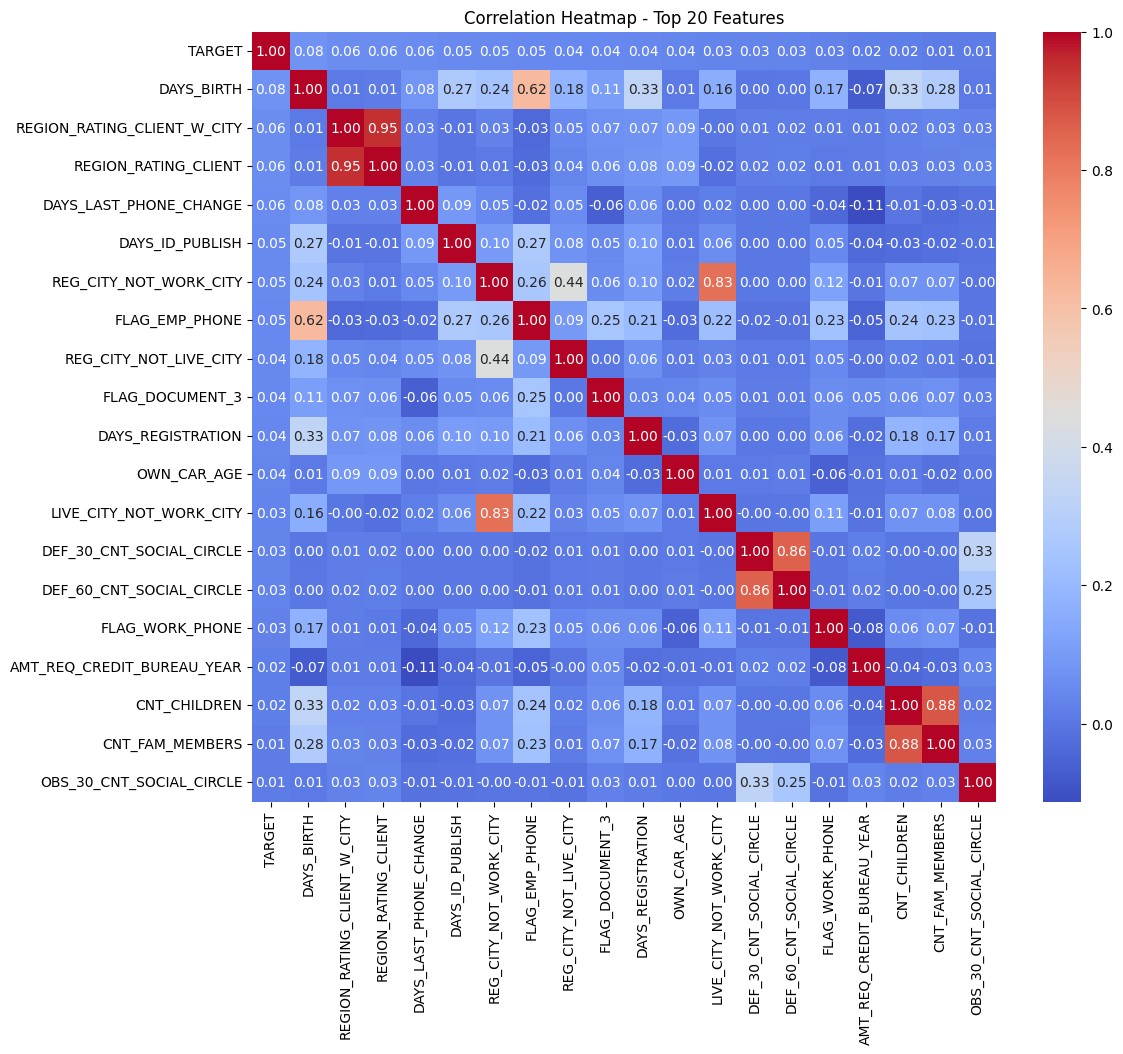

In [4]:
# Visualisasi Correlation Heatmap (Top Features)
top_features = correlations.head(20).index
plt.figure(figsize=(12, 10))
sns.heatmap(app_train[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap - Top 20 Features')
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')

In [5]:
# ====================================================================================================
# TAHAP 5: DATA CLEANING & PREPROCESSING
# ====================================================================================================

def preprocess_data(df, is_train=True):
    '''Preprocessing function for cleaning and encoding'''
    
    df = df.copy()
    
    # 1. Remove columns with >50% missing values
    missing_threshold = 0.5
    missing_cols = [col for col in df.columns 
                   if df[col].isnull().sum() / len(df) > missing_threshold]
    df = df.drop(columns=missing_cols)
    print(f"Removed {len(missing_cols)} columns with >{missing_threshold*100}% missing")
    
    # 2. Separate numeric and categorical columns
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    
    if is_train and 'TARGET' in numeric_cols:
        numeric_cols.remove('TARGET')
    if 'SK_ID_CURR' in numeric_cols:
        numeric_cols.remove('SK_ID_CURR')
    
    # 3. Impute missing values
    # Numeric: median imputation
    num_imputer = SimpleImputer(strategy='median')
    df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])
    
    # Categorical: mode imputation
    if categorical_cols:
        cat_imputer = SimpleImputer(strategy='most_frequent')
        df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])
    
    # 4. Encode categorical variables
    le_dict = {}
    for col in categorical_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        le_dict[col] = le
    
    # 5. Handle outliers (optional - using IQR method)
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 3 * IQR
        upper_bound = Q3 + 3 * IQR
        df[col] = df[col].clip(lower_bound, upper_bound)
    
    return df, le_dict

# Apply preprocessing
app_train_clean, label_encoders = preprocess_data(app_train, is_train=True)
print(f"\\nCleaned training data shape: {app_train_clean.shape}")

Removed 41 columns with >50.0% missing
\nCleaned training data shape: (307511, 81)


In [6]:
# ====================================================================================================
# TAHAP 6: FEATURE ENGINEERING
# ====================================================================================================

def feature_engineering(df):
    '''Create derived features'''
    
    df = df.copy()
    
    # 1. Income-related features
    df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)
    df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)
    df['CREDIT_TERM'] = df['AMT_ANNUITY'] / (df['AMT_CREDIT'] + 1)
    df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 1)
    
    # 2. Age-related features
    df['DAYS_EMPLOYED_PERCENT'] = df['DAYS_EMPLOYED'] / (df['DAYS_BIRTH'] + 1)
    df['AGE_YEARS'] = -df['DAYS_BIRTH'] / 365
    df['EMPLOYMENT_YEARS'] = -df['DAYS_EMPLOYED'] / 365
    
    # 3. Document flags
    doc_cols = [col for col in df.columns if 'FLAG_DOCUMENT' in col]
    df['TOTAL_DOCUMENTS'] = df[doc_cols].sum(axis=1)
    
    # 4. External sources combination
    if all(col in df.columns for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
        df['EXT_SOURCE_MEAN'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
        df['EXT_SOURCE_STD'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].std(axis=1)
        df['EXT_SOURCE_PROD'] = df['EXT_SOURCE_1'] * df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']
    
    return df

# Aggregate Bureau Data
def aggregate_bureau(bureau_df, bureau_balance_df):
    '''Aggregate bureau data for each client'''
    
    # Merge bureau with bureau_balance
    bureau_full = bureau_df.merge(bureau_balance_df, on='SK_ID_BUREAU', how='left')
    
    # Aggregate by SK_ID_CURR
    agg_dict = {
        'DAYS_CREDIT': ['min', 'max', 'mean'],
        'CREDIT_DAY_OVERDUE': ['max', 'mean'],
        'DAYS_CREDIT_ENDDATE': ['min', 'max', 'mean'],
        'AMT_CREDIT_MAX_OVERDUE': ['max', 'mean'],
        'AMT_CREDIT_SUM': ['max', 'mean', 'sum'],
        'AMT_CREDIT_SUM_DEBT': ['max', 'mean', 'sum'],
        'CREDIT_TYPE': ['nunique'],
        'DAYS_CREDIT_UPDATE': ['min', 'max', 'mean']
    }
    
    bureau_agg = bureau_df.groupby('SK_ID_CURR').agg(agg_dict)
    bureau_agg.columns = ['BUREAU_' + '_'.join(col).upper() for col in bureau_agg.columns]
    bureau_agg = bureau_agg.reset_index()
    
    return bureau_agg

# Aggregate Previous Applications
def aggregate_previous(prev_df):
    '''Aggregate previous application data'''
    
    agg_dict = {
        'AMT_ANNUITY': ['min', 'max', 'mean'],
        'AMT_APPLICATION': ['min', 'max', 'mean'],
        'AMT_CREDIT': ['min', 'max', 'mean'],
        'AMT_DOWN_PAYMENT': ['min', 'max', 'mean'],
        'HOUR_APPR_PROCESS_START': ['min', 'max', 'mean'],
        'RATE_DOWN_PAYMENT': ['min', 'max', 'mean'],
        'DAYS_DECISION': ['min', 'max', 'mean'],
        'CNT_PAYMENT': ['mean', 'sum'],
        'NAME_CONTRACT_STATUS': lambda x: (x == 'Approved').sum()
    }
    
    prev_agg = prev_df.groupby('SK_ID_CURR').agg(agg_dict)
    prev_agg.columns = ['PREV_' + '_'.join(str(col)).upper() for col in prev_agg.columns]
    prev_agg = prev_agg.reset_index()
    
    return prev_agg

# Apply feature engineering
app_train_fe = feature_engineering(app_train_clean)
print(f"\\nFeatures after engineering: {app_train_fe.shape[1]}")

\nFeatures after engineering: 89


In [25]:
# ====================================================================================================
# TAHAP 7: HANDLING IMBALANCED DATA & MODEL PREPARATION
# ====================================================================================================

# Prepare features and target
X = app_train_fe.drop(['SK_ID_CURR', 'TARGET'], axis=1, errors='ignore')
y = app_train_fe['TARGET']

# Fill any remaining NaN values
X = X.fillna(X.median())

# Split data
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\\nTraining set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Class distribution in training:\\n{y_train.value_counts(normalize=True)}")

# Apply SMOTE to balance training data
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"\\nAfter SMOTE:")
print(f"Training set: {X_train_balanced.shape}")
print(f"Class distribution:\\n{pd.Series(y_train_balanced).value_counts(normalize=True)}")

# Feature Scaling (for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_val_scaled = scaler.transform(X_val)

\nTraining set: (246008, 87)
Validation set: (61503, 87)
Class distribution in training:\nTARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64
\nAfter SMOTE:
Training set: (452296, 87)
Class distribution:\nTARGET
0    0.5
1    0.5
Name: proportion, dtype: float64


TRAINING MODEL 1: LOGISTIC REGRESSION
Logistic Regression AUC-ROC: 0.6811
Gini Coefficient: 0.3621
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.73      0.83     56538
           1       0.15      0.52      0.23      4965

    accuracy                           0.72     61503
   macro avg       0.55      0.63      0.53     61503
weighted avg       0.88      0.72      0.78     61503



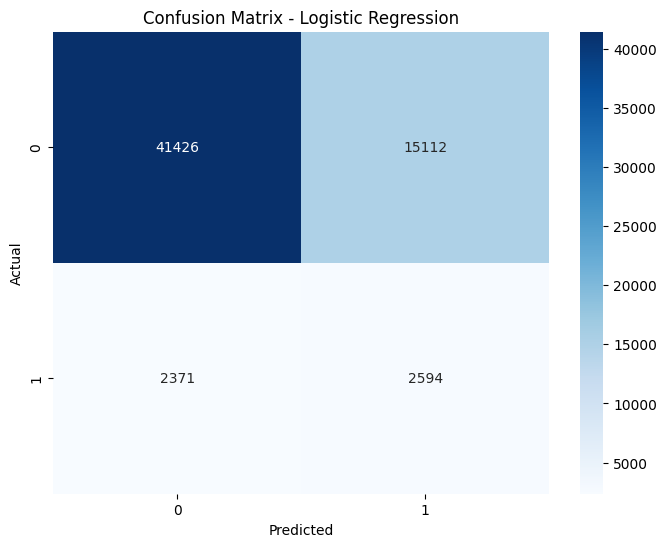

In [32]:
# ====================================================================================================
# TAHAP 8: MODEL 1 - LOGISTIC REGRESSION
# ====================================================================================================

print("" + "="*80)
print("TRAINING MODEL 1: LOGISTIC REGRESSION")
print("="*80)

# Train Logistic Regression
lr_model = LogisticRegression(
    solver='lbfgs',
    penalty='l2',
    max_iter=2000,
    random_state=42,
    n_jobs=-1
)

lr_model.fit(X_train_scaled, y_train_balanced)

# Predictions
y_pred_lr = lr_model.predict(X_val_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_val_scaled)[:, 1]

# Evaluation
auc_lr = roc_auc_score(y_val, y_pred_proba_lr)
print(f"Logistic Regression AUC-ROC: {auc_lr:.4f}")
print(f"Gini Coefficient: {(2 * auc_lr - 1):.4f}")
print("Classification Report:")
print(classification_report(y_val, y_pred_lr))

# Confusion Matrix
cm_lr = confusion_matrix(y_val, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('cm_logistic_regression.png', dpi=300, bbox_inches='tight')

TRAINING MODEL 2: LIGHTGBM
Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.750013
[100]	valid_0's auc: 0.758693
[150]	valid_0's auc: 0.760723
[200]	valid_0's auc: 0.761959
[250]	valid_0's auc: 0.762249
[300]	valid_0's auc: 0.761957
Early stopping, best iteration is:
[264]	valid_0's auc: 0.762382
LightGBM AUC-ROC: 0.7624
Gini Coefficient: 0.5248
nClassification Report:
              precision    recall  f1-score   support

           0       0.96      0.71      0.82     56538
           1       0.17      0.68      0.27      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.69      0.54     61503
weighted avg       0.90      0.71      0.77     61503



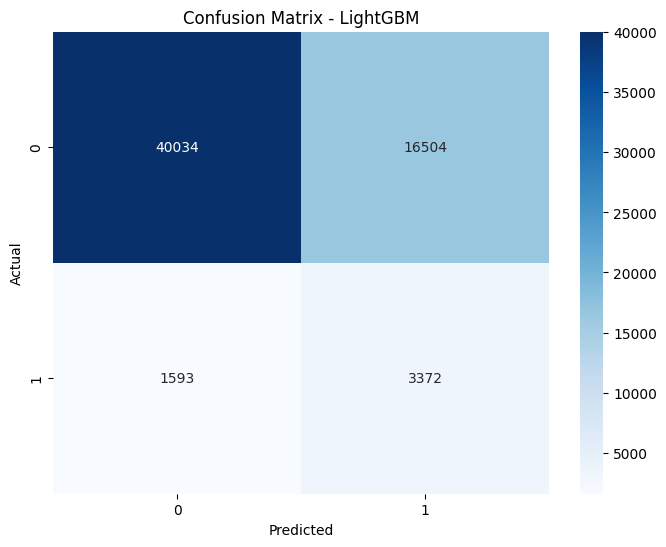

In [43]:
# ====================================================================================================
# TAHAP 9: MODEL 2 - LIGHTGBM
# ====================================================================================================

print("" + "="*80)
print("TRAINING MODEL 2: LIGHTGBM")
print("="*80)

# LightGBM parameters
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'max_depth': 8,
    'min_child_samples': 20,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': 42,
    'n_estimators': 1000,
    'verbose': -1,
    'is_unbalance': True
}

# Train LightGBM
lgb_model = lgb.LGBMClassifier(**lgb_params)
lgb_model.fit(
    X_train, y_train,  # Use original imbalanced data with is_unbalance=True
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(50)]
)

# Predictions
y_pred_lgb = lgb_model.predict(X_val)
y_pred_proba_lgb = lgb_model.predict_proba(X_val)[:, 1]

# Evaluation
auc_lgb = roc_auc_score(y_val, y_pred_proba_lgb)
print(f"LightGBM AUC-ROC: {auc_lgb:.4f}")
print(f"Gini Coefficient: {(2 * auc_lgb - 1):.4f}")
print("nClassification Report:")
print(classification_report(y_val, y_pred_lgb))

# Confusion Matrix
cm_lgbm = confusion_matrix(y_val, y_pred_lgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - LightGBM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('cm_lightgbm.png', dpi=300, bbox_inches='tight')

TRAINING MODEL 3: XGBOOST
[0]	validation_0-auc:0.71072
[50]	validation_0-auc:0.74953
[100]	validation_0-auc:0.75552
[150]	validation_0-auc:0.75693
[200]	validation_0-auc:0.75731
[250]	validation_0-auc:0.75680
[300]	validation_0-auc:0.75604
[350]	validation_0-auc:0.75527
[400]	validation_0-auc:0.75423
[450]	validation_0-auc:0.75391
[500]	validation_0-auc:0.75279
[550]	validation_0-auc:0.75185
[600]	validation_0-auc:0.75117
[650]	validation_0-auc:0.74993
[700]	validation_0-auc:0.74901
[750]	validation_0-auc:0.74832
[800]	validation_0-auc:0.74737
[850]	validation_0-auc:0.74678
[900]	validation_0-auc:0.74563
[950]	validation_0-auc:0.74447
[999]	validation_0-auc:0.74391
XGBoost AUC-ROC: 0.7439
Gini Coefficient: 0.4878
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.88      0.91     56538
           1       0.23      0.42      0.30      4965

    accuracy                           0.84     61503
   macro avg       0.59      0.65   

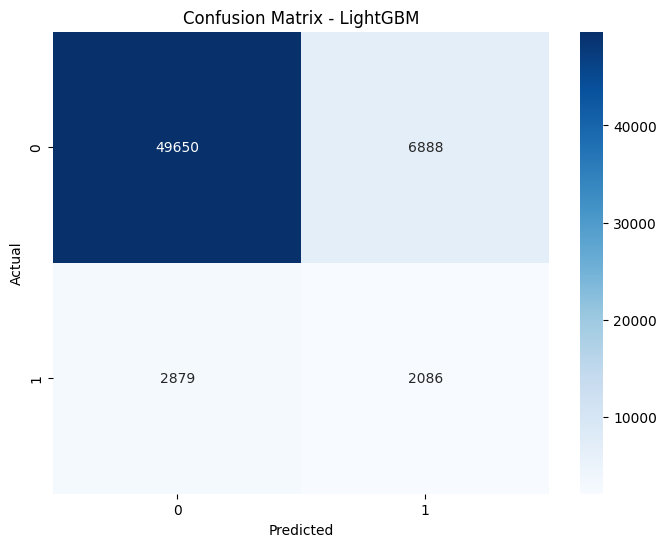

In [42]:
# ====================================================================================================
# TAHAP 10: MODEL 3 - XGBOOST
# ====================================================================================================

print("" + "="*80)
print("TRAINING MODEL 3: XGBOOST")
print("="*80)

# Calculate scale_pos_weight for imbalanced data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_params = {
    'max_depth': 8,
    'learning_rate': 0.05,
    'n_estimators': 1000,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 1,
    'gamma': 0.1,
    'reg_alpha': 0.1,
    'reg_lambda': 1,
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42
}

xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

# Predictions
y_pred_xgb = xgb_model.predict(X_val)
y_pred_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]

# Evaluation
auc_xgb = roc_auc_score(y_val, y_pred_proba_xgb)
print(f"XGBoost AUC-ROC: {auc_xgb:.4f}")
print(f"Gini Coefficient: {(2 * auc_xgb - 1):.4f}")
print("Classification Report:")
print(classification_report(y_val, y_pred_xgb))

# Confusion Matrix
cm_xgb = confusion_matrix(y_val, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - LightGBM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('cm_xgboost.png', dpi=300, bbox_inches='tight')

In [44]:
# ====================================================================================================
# TAHAP 11: COMPARATIVE MODEL EVALUATION (dengan AKURASI)
# ====================================================================================================

from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score

print("="*80)
print("MODEL COMPARISON")
print("="*80)

# =======================================================================================
# ROC Curve Comparison
# =======================================================================================
plt.figure(figsize=(10, 8))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_val, y_pred_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})', linewidth=2)

# LightGBM
fpr_lgb, tpr_lgb, _ = roc_curve(y_val, y_pred_proba_lgb)
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {auc_lgb:.4f})', linewidth=2)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, y_pred_proba_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})', linewidth=2)

# Random classifier line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.savefig('roc_curve_comparison.png', dpi=300, bbox_inches='tight')
plt.close()

# =======================================================================================
# Tambahkan Akurasi
# =======================================================================================
acc_lr = accuracy_score(y_val, y_pred_lr)
acc_lgb = accuracy_score(y_val, y_pred_lgb)
acc_xgb = accuracy_score(y_val, y_pred_xgb)

# =======================================================================================
# Tabel Ringkasan Performa Model
# =======================================================================================
performance_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'LightGBM', 'XGBoost'],
    'AUC-ROC': [auc_lr, auc_lgb, auc_xgb],
    'Gini': [2*auc_lr - 1, 2*auc_lgb - 1, 2*auc_xgb - 1],
    'Accuracy': [acc_lr, acc_lgb, acc_xgb]
})

print("\nModel Performance Summary:")
print(performance_summary.to_string(index=False))

MODEL COMPARISON

Model Performance Summary:
              Model  AUC-ROC     Gini  Accuracy
Logistic Regression 0.681059 0.362119  0.715737
           LightGBM 0.762382 0.524764  0.705754
            XGBoost 0.743911 0.487821  0.841195


In [ ]:
# ====================================================================================================
# TAHAP 9: HYPERPARAMETER TUNING DENGAN RANDOMIZED SEARCH (LightGBM)
# ====================================================================================================

from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint as sp_randint, uniform as sp_uniform

# =======================================================================================
# MODEL DASAR
# =======================================================================================
lgbm = LGBMClassifier(
    objective='binary',
    metric='auc',
    boosting_type='gbdt',
    random_state=42,
    n_jobs=-1
)

# =======================================================================================
# DEFINISIKAN RUANG HYPERPARAMETER
# =======================================================================================
param_dist = {
    'num_leaves': sp_randint(20, 100),
    'max_depth': sp_randint(3, 15),
    'learning_rate': sp_uniform(0.01, 0.2),
    'n_estimators': sp_randint(100, 1000),
    'subsample': sp_uniform(0.6, 0.4),
    'colsample_bytree': sp_uniform(0.6, 0.4),
    'reg_alpha': sp_uniform(0, 1),
    'reg_lambda': sp_uniform(0, 1),
    'min_child_samples': sp_randint(10, 100)
}

# =======================================================================================
# RANDOM SEARCH CV
# =======================================================================================
random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=50,                # jumlah kombinasi parameter yang diuji
    scoring='roc_auc',        # metrik utama
    cv=3,                     # 3-fold cross validation
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# =======================================================================================
# FIT MODEL MENGGUNAKAN DATA TRAINING
# =======================================================================================
random_search.fit(X_train_balanced, y_train_balanced)

# =======================================================================================
# CETAK HASIL TERBAIK
# =======================================================================================
print("\nBest Parameters Found:")
print(random_search.best_params_)

print("\nBest AUC Score from CV:")
print(random_search.best_score_)

# =======================================================================================
# EVALUASI DI DATA VALIDASI
# =======================================================================================
best_model = random_search.best_estimator_

y_val_pred_proba = best_model.predict_proba(X_val)[:, 1]
auc_val = roc_auc_score(y_val, y_val_pred_proba)

print(f"\nValidation AUC after Tuning: {auc_val:.4f}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits

Best Parameters Found:
{'colsample_bytree': np.float64(0.7003442109386645), 'learning_rate': np.float64(0.04686673486627401), 'max_depth': 9, 'min_child_samples': 18, 'n_estimators': 740, 'num_leaves': 77, 'reg_alpha': np.float64(0.9152137276264805), 'reg_lambda': np.float64(0.44235222973110444), 'subsample': np.float64(0.6959149436629612)}

Best AUC Score from CV:
0.9686531611127256

Validation AUC after Tuning: 0.7551


In [85]:
# ====================================================================================================
# FINAL INFERENCE DENGAN PIPELINE YANG SAMA (Logistic Regression, LightGBM, XGBoost, Best Model)
# + Pemilihan Threshold Terbaik Berdasarkan ROC Curve
# ====================================================================================================

# LOAD TEST DATA
app_test = pd.read_csv('dataset/application_test.csv')

# ====================================================================================================
# PREPROCESSING TEST (gunakan encoder & imputer hasil training)
# ====================================================================================================
def preprocess_test(df, le_dict, train_columns):
    df = df.copy()
    
    # Drop kolom dengan missing > 50% seperti di training
    missing_threshold = 0.5
    missing_cols = [col for col in df.columns if df[col].isnull().sum()/len(df) > missing_threshold]
    df = df.drop(columns=missing_cols, errors='ignore')
    
    # Pisahkan tipe data
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    
    # Imputasi nilai hilang
    num_imputer = SimpleImputer(strategy='median')
    df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])
    if categorical_cols:
        cat_imputer = SimpleImputer(strategy='most_frequent')
        df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])
    
    # Gunakan encoder hasil training (LabelEncoder)
    for col, le in le_dict.items():
        if col in df.columns:
            df[col] = df[col].astype(str)
            df[col] = df[col].map(lambda x: le.transform([x])[0] if x in le.classes_ else 0)
    
    return df


# Preprocess + Feature Engineering
app_test_clean = preprocess_test(app_test, label_encoders, X.columns)
app_test_fe = feature_engineering(app_test_clean)

# Sesuaikan kolom dengan training
X_test = app_test_fe.reindex(columns=X.columns, fill_value=0)


# ====================================================================================================
# PILIH THRESHOLD TERBAIK DARI VALIDASI (gunakan Logistic Regression sebagai acuan)
# ====================================================================================================
print("="*90)
print("🔹 Menentukan Threshold Terbaik Berdasarkan ROC Curve (Youden’s J)")
print("="*90)

y_val_pred_proba = lr_model.predict_proba(X_val_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, y_val_pred_proba)
j_scores = tpr - fpr
best_threshold = thresholds[np.argmax(j_scores)]
best_auc = roc_auc_score(y_val, y_val_pred_proba)

print(f"✅ Best Threshold (LogReg, Youden's J): {best_threshold:.4f}")
print(f"✅ AUC Logistic Regression Validation: {best_auc:.4f}")


# ====================================================================================================
# LOGISTIC REGRESSION (dengan SCALER)
# ====================================================================================================
print("\n" + "="*90)
print("🔹 Logistic Regression Inference")
print("="*90)

X_test_scaled = scaler.transform(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
y_pred_label_lr = (y_pred_proba_lr >= best_threshold).astype(int)

submission_lr = pd.DataFrame({
    'SK_ID_CURR': app_test['SK_ID_CURR'],
    'TARGET_PROBA': y_pred_proba_lr,
    'TARGET_LABEL': y_pred_label_lr
})
submission_lr.to_csv('submission_inference_logreg.csv', index=False)
print("✅ Logistic Regression inference selesai → submission_inference_logreg.csv")
display(submission_lr.head(10))


# ====================================================================================================
# LIGHTGBM (tanpa scaling)
# ====================================================================================================
print("\n" + "="*90)
print("🔹 LightGBM Inference")
print("="*90)

y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]
y_pred_label_lgb = (y_pred_proba_lgb >= best_threshold).astype(int)

submission_lgb = pd.DataFrame({
    'SK_ID_CURR': app_test['SK_ID_CURR'],
    'TARGET_PROBA': y_pred_proba_lgb,
    'TARGET_LABEL': y_pred_label_lgb
})
submission_lgb.to_csv('submission_inference_lightgbm.csv', index=False)
print("✅ LightGBM inference selesai → submission_inference_lightgbm.csv")
display(submission_lgb.head(10))


# ====================================================================================================
# XGBOOST (tanpa scaling)
# ====================================================================================================
print("\n" + "="*90)
print("🔹 XGBoost Inference")
print("="*90)

y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_label_xgb = (y_pred_proba_xgb >= best_threshold).astype(int)

submission_xgb = pd.DataFrame({
    'SK_ID_CURR': app_test['SK_ID_CURR'],
    'TARGET_PROBA': y_pred_proba_xgb,
    'TARGET_LABEL': y_pred_label_xgb
})
submission_xgb.to_csv('submission_inference_xgboost.csv', index=False)
print("✅ XGBoost inference selesai → submission_inference_xgboost.csv")
display(submission_xgb.head(10))


# ====================================================================================================
# BEST MODEL HASIL HYPERPARAMETER TUNING (tanpa scaling jika tree-based)
# ====================================================================================================
print("\n" + "="*90)
print("🔹 Best Model (RandomizedSearchCV) Inference")
print("="*90)

y_val_pred_proba_best = best_model.predict_proba(X_val)[:, 1]
auc_val = roc_auc_score(y_val, y_val_pred_proba_best)
print(f"✅ Validation AUC (Best Model): {auc_val:.4f}")

y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]
y_pred_label_best = (y_pred_proba_best >= best_threshold).astype(int)

submission_best = pd.DataFrame({
    'SK_ID_CURR': app_test['SK_ID_CURR'],
    'TARGET_PROBA': y_pred_proba_best,
    'TARGET_LABEL': y_pred_label_best
})
submission_best.to_csv('submission_inference_bestmodel.csv', index=False)
print("✅ Best Model inference selesai → submission_inference_bestmodel.csv")
display(submission_best.head(10))


# ====================================================================================================
# 📊 Ringkasan Distribusi Probabilitas Semua Model
# ====================================================================================================
def summary_proba(name, y_pred):
    q = np.percentile(y_pred, [0, 1, 5, 25, 50, 75, 90, 99, 100])
    print(f"\n📈 {name} Percentiles:", np.round(q, 6))
    print(f"{name} min/max/mean:", y_pred.min(), y_pred.max(), y_pred.mean())

summary_proba("LogReg", y_pred_proba_lr)
summary_proba("LightGBM", y_pred_proba_lgb)
summary_proba("XGBoost", y_pred_proba_xgb)
summary_proba("BestModel", y_pred_proba_best)


🔹 Menentukan Threshold Terbaik Berdasarkan ROC Curve (Youden’s J)
✅ Best Threshold (LogReg, Youden's J): 0.3963
✅ AUC Logistic Regression Validation: 0.6811

🔹 Logistic Regression Inference
✅ Logistic Regression inference selesai → submission_inference_logreg.csv


,SK_ID_CURR,TARGET_PROBA,TARGET_LABEL
0,100001,0.499328,1
1,100005,0.547936,1
2,100013,0.086308,0
3,100028,0.035004,0
4,100038,0.448079,1
5,100042,0.098484,0
6,100057,0.082444,0
7,100065,0.336566,0
8,100066,0.282917,0
9,100067,0.341282,0



🔹 LightGBM Inference
✅ LightGBM inference selesai → submission_inference_lightgbm.csv


,SK_ID_CURR,TARGET_PROBA,TARGET_LABEL
0,100001,0.353006,0
1,100005,0.683769,1
2,100013,0.104669,0
3,100028,0.374439,0
4,100038,0.582061,1
5,100042,0.270824,0
6,100057,0.269842,0
7,100065,0.422508,1
8,100066,0.205845,0
9,100067,0.556712,1



🔹 XGBoost Inference
✅ XGBoost inference selesai → submission_inference_xgboost.csv


,SK_ID_CURR,TARGET_PROBA,TARGET_LABEL
0,100001,0.097626,0
1,100005,0.554924,1
2,100013,0.025241,0
3,100028,0.243456,0
4,100038,0.409654,1
5,100042,0.109217,0
6,100057,0.059360,0
7,100065,0.166603,0
8,100066,0.061447,0
9,100067,0.168718,0



🔹 Best Model (RandomizedSearchCV) Inference
✅ Validation AUC (Best Model): 0.7551
✅ Best Model inference selesai → submission_inference_bestmodel.csv


,SK_ID_CURR,TARGET_PROBA,TARGET_LABEL
0,100001,0.047339,0
1,100005,0.278678,0
2,100013,0.027300,0
3,100028,0.096063,0
4,100038,0.249239,0
5,100042,0.046926,0
6,100057,0.044705,0
7,100065,0.118137,0
8,100066,0.020428,0
9,100067,0.135260,0



📈 LogReg Percentiles: [0.       0.002073 0.02258  0.161537 0.365253 0.634988 0.852187 0.999988
 1.      ]
LogReg min/max/mean: 1.4813420280383428e-83 1.0 0.41226882963465933

📈 LightGBM Percentiles: [0.017285 0.053427 0.095094 0.222051 0.37467  0.559916 0.69748  0.835207
 0.929496]
LightGBM min/max/mean: 0.017284792260386598 0.9294959657192987 0.3966595471334688

📈 XGBoost Percentiles: [1.60000e-05 1.99000e-03 8.07400e-03 5.22380e-02 1.48739e-01 3.28777e-01
 5.27146e-01 7.77920e-01 9.46524e-01]
XGBoost min/max/mean: 1.5704114e-05 0.9465243 0.21470721

📈 BestModel Percentiles: [0.001745 0.00646  0.012487 0.034843 0.076114 0.163284 0.289356 0.553759
 0.889338]
BestModel min/max/mean: 0.0017453225518459117 0.889337958301127 0.11999360101426605
